In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
import pandas as pd

### Analyse Exploratoire

In [22]:
df_math = pd.read_csv(r"..\data\student-mat.csv", index_col=0)
df_math.head(5)

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,6,5,6,6
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,4,5,5,6
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,10,7,8,10
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,2,15,14,15
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,4,6,10,10


In [23]:
df_port = pd.read_csv(r"..\data\student-por.csv", index_col=0)
df_port.head(5)

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
school,,,,,,,,,,,,,,,,,,,,,
GP,F,18,U,GT3,A,4,4,at_home,teacher,course,...,4,3,4,1,1,3,4,0,11,11
GP,F,17,U,GT3,T,1,1,at_home,other,course,...,5,3,3,1,1,3,2,9,11,11
GP,F,15,U,LE3,T,1,1,at_home,other,other,...,4,3,2,2,3,3,6,12,13,12
GP,F,15,U,GT3,T,4,2,health,services,home,...,3,2,2,1,1,5,0,14,14,14
GP,F,16,U,GT3,T,3,3,other,other,home,...,4,3,2,1,2,5,0,11,13,13


In [24]:
# merge des deux datasets pour les étudiants appartenant aux deux datasets
df_merge = pd.merge(df_math,df_port, on=["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob","reason","nursery","internet"])
print(df_merge.info()) # on retrouve bien le 382 du fichier student-merge.R

<class 'pandas.core.frame.DataFrame'>
Index: 382 entries, GP to MS
Data columns (total 52 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sex           382 non-null    object
 1   age           382 non-null    int64 
 2   address       382 non-null    object
 3   famsize       382 non-null    object
 4   Pstatus       382 non-null    object
 5   Medu          382 non-null    int64 
 6   Fedu          382 non-null    int64 
 7   Mjob          382 non-null    object
 8   Fjob          382 non-null    object
 9   reason        382 non-null    object
 10  guardian_x    382 non-null    object
 11  traveltime_x  382 non-null    int64 
 12  studytime_x   382 non-null    int64 
 13  failures_x    382 non-null    int64 
 14  schoolsup_x   382 non-null    object
 15  famsup_x      382 non-null    object
 16  paid_x        382 non-null    object
 17  activities_x  382 non-null    object
 18  nursery       382 non-null    object
 19  higher_x     

In [20]:
# Voir toutes les colonnes du dataframe fusionné
print("Colonnes disponibles :")
print(df_merge.columns.tolist())

Colonnes disponibles :
['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian_x', 'traveltime_x', 'studytime_x', 'failures_x', 'schoolsup_x', 'famsup_x', 'paid_x', 'activities_x', 'nursery', 'higher_x', 'internet', 'romantic_x', 'famrel_x', 'freetime_x', 'goout_x', 'Dalc_x', 'Walc_x', 'health_x', 'absences_x', 'G1_x', 'G2_x', 'G3_x', 'guardian_y', 'traveltime_y', 'studytime_y', 'failures_y', 'schoolsup_y', 'famsup_y', 'paid_y', 'activities_y', 'higher_y', 'romantic_y', 'famrel_y', 'freetime_y', 'goout_y', 'Dalc_y', 'Walc_y', 'health_y', 'absences_y', 'G1_y', 'G2_y', 'G3_y']


In [25]:
df_merge.describe()

,age,Medu,Fedu,traveltime_x,studytime_x,failures_x,famrel_x,freetime_x,goout_x,Dalc_x,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,...,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,16.586387,2.806283,2.565445,1.442408,2.034031,0.290576,3.939791,3.222513,3.112565,1.473822,...,3.942408,3.230366,3.117801,1.476440,2.290576,3.575916,3.672775,12.112565,12.238220,12.515707
std,1.173470,1.086381,1.096240,0.695378,0.845798,0.729481,0.921620,0.988233,1.131927,0.886229,...,0.908884,0.985096,1.133710,0.886303,1.282577,1.404248,4.905965,2.556531,2.468341,2.945438
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,5.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,10.000000,11.000000,11.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,12.000000,12.000000,13.000000
75%,17.000000,4.000000,4.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,14.000000,14.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


### Analyse bivariée

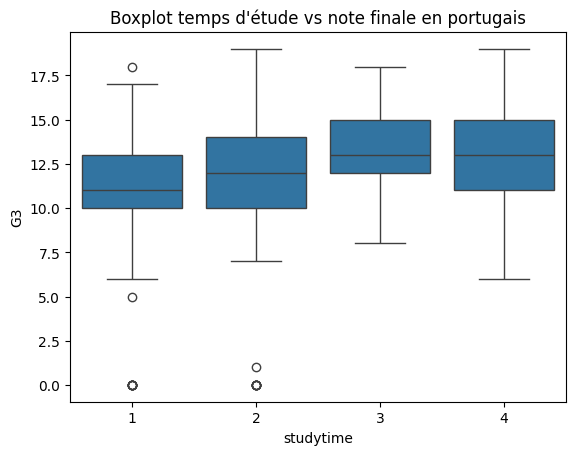

In [38]:
# Boxplot temps d'étude vs note finale en portugais
sns.boxplot(x='studytime', y='G3', data=df_port)
plt.title("Boxplot temps d'étude vs note finale en portugais")
plt.show()

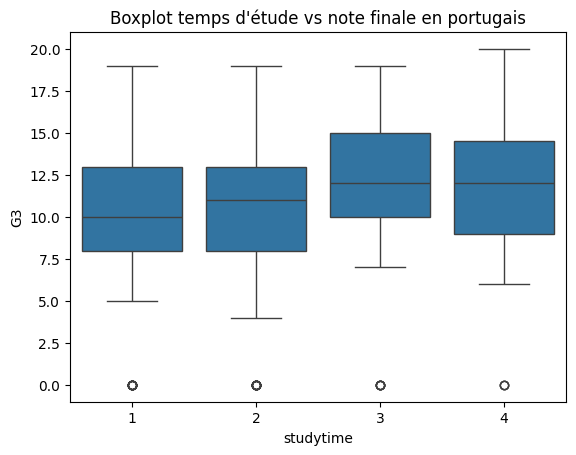

In [39]:
# Boxplot temps d'étude vs note finale en portugais
sns.boxplot(x='studytime', y='G3', data=df_math)
plt.title("Boxplot temps d'étude vs note finale en portugais")
plt.show()

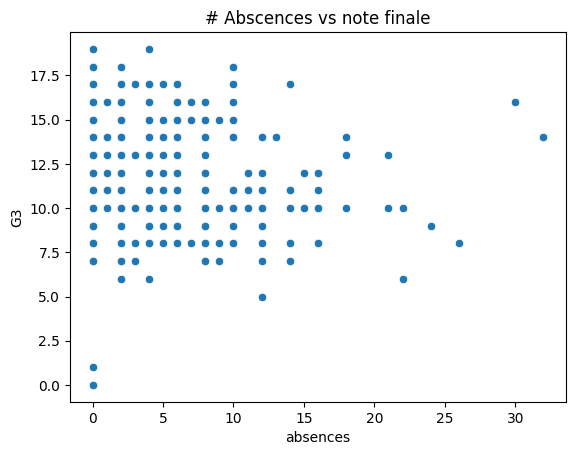

          absences        G3
absences  1.000000 -0.091379
G3       -0.091379  1.000000


In [ ]:
# Abscences vs note finale en portugais
sns.scatterplot(x='absences', y='G3', data=df_port)
plt.title("Abscences vs note finale")
plt.show()

print(df_port[['absences', 'G3']].corr())

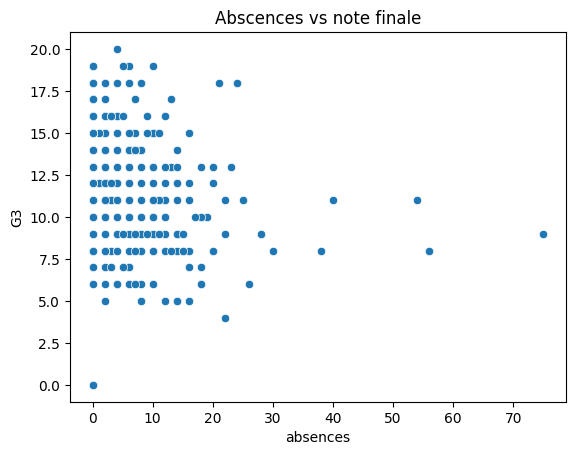

          absences        G3
absences  1.000000  0.034247
G3        0.034247  1.000000


In [41]:
# Abscences vs note finale en maths
sns.scatterplot(x='absences', y='G3', data=df_math)
plt.title("Abscences vs note finale")
plt.show()

print(df_math[['absences', 'G3']].corr())

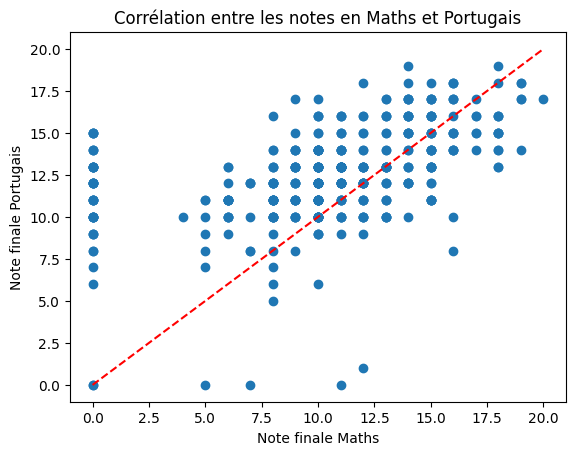

In [47]:
# Corrélation entre les notes de maths et portugais
plt.scatter(df_merge['G3_x'], df_merge['G3_y'])
plt.xlabel('Note finale Maths')
plt.ylabel('Note finale Portugais')
plt.title('Corrélation entre les notes en Maths et Portugais')
plt.plot([0, 20], [0, 20], 'r--', label='y=x')
plt.show()

In [37]:
# Créer une nouvelle variables de moy des notes finales

df_merge['G3_mean'] = (df_merge['G3_x'] + df_merge['G3_y']) / 2

print(df_merge[['G3_x', 'G3_y', 'G3_mean']].head())

        G3_x  G3_y  G3_mean
school                     
GP         6    11      8.5
GP         6    11      8.5
GP        10    12     11.0
GP        15    14     14.5
GP        10    13     11.5


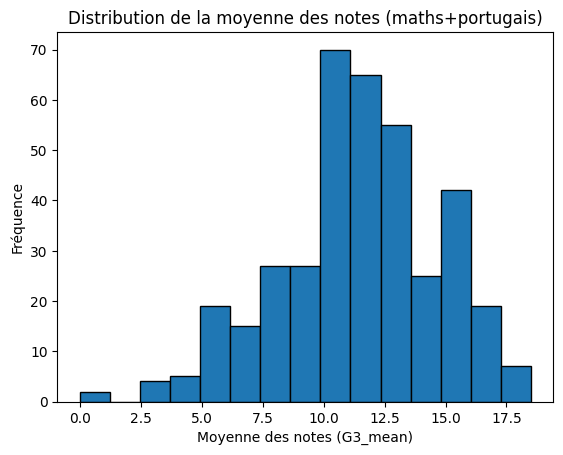

count    382.000000
mean      11.451571
std        3.313202
min        0.000000
25%        9.500000
50%       11.500000
75%       13.500000
max       18.500000
Name: G3_mean, dtype: float64


In [52]:
# Distribution de la moyenne des notes
plt.hist(df_merge['G3_mean'], bins=15, edgecolor = "black")
plt.xlabel('Moyenne des notes (G3_mean)')
plt.ylabel('Fréquence')
plt.title('Distribution de la moyenne des notes (maths+portugais)')
plt.show()

print(df_merge['G3_mean'].describe())